# 02 · Modeling & Evaluation
Trains and compares two models on the *same* preprocessed splits:
1. **Baseline** — TF-IDF + Logistic Regression
2. **Bidirectional LSTM** — the project's deep learning model

All training/evaluation logic lives in `src/`; this notebook calls it and inspects results, it does not reimplement the pipeline.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import json
import pandas as pd
import matplotlib.pyplot as plt

from src.config import SPLITS_DIR, METRICS_DIR, CLASS_NAMES
from src.data.preprocessing import run_preprocessing_pipeline

plt.rcParams['figure.dpi'] = 110

## 1. Rebuild the processed splits (idempotent)
Re-running this is safe and fast — it re-derives `data/processed/splits/*.parquet` from `data/raw/Tweets.csv` deterministically (fixed seed in `src/config.py`).

In [2]:
splits = run_preprocessing_pipeline(save=True)
{k: len(v) for k, v in splits.items()}

2026-09-12 01:00:46,806 | INFO     | src.data.preprocessing | Loading raw dataset from /home/claude/work/airline-sentiment-lstm/data/raw/Tweets.csv


2026-09-12 01:00:46,956 | INFO     | src.data.validation | Validation passed: 14640 rows, 15 columns, 3 unique labels.


2026-09-12 01:00:47,126 | INFO     | src.data.preprocessing | Cleaning removed 414 rows (14640 -> 14226).


2026-09-12 01:00:47,238 | INFO     | src.data.preprocessing | Split sizes -> train: 9958, val: 2134, test: 2134


2026-09-12 01:00:47,298 | INFO     | src.data.preprocessing | Saved train split (9958 rows) to /home/claude/work/airline-sentiment-lstm/data/processed/splits/train.parquet


2026-09-12 01:00:47,307 | INFO     | src.data.preprocessing | Saved val split (2134 rows) to /home/claude/work/airline-sentiment-lstm/data/processed/splits/val.parquet


2026-09-12 01:00:47,315 | INFO     | src.data.preprocessing | Saved test split (2134 rows) to /home/claude/work/airline-sentiment-lstm/data/processed/splits/test.parquet


{'train': 9958, 'val': 2134, 'test': 2134}

## 2. Train the baseline (TF-IDF + Logistic Regression)

In [3]:
from src.training.train_baseline import train_baseline
baseline_summary = train_baseline()
baseline_summary

2026-09-12 01:00:48,428 | INFO     | src.training.train_baseline | Baseline test accuracy: 0.7985 (trained in 1.0s)


2026-09-12 01:00:48,621 | INFO     | src.training.train_baseline | Saved baseline model to /home/claude/work/airline-sentiment-lstm/models/baseline_tfidf_logreg.joblib


{'test_accuracy': 0.7985004686035614, 'train_seconds': 0.9530441761016846}

## 3. Train the LSTM
This cell runs the same training loop as `python -m src.training.train_lstm` — early stopping on validation loss restores the best-performing epoch's weights.

In [4]:
from src.training.train_lstm import train_lstm
lstm_summary = train_lstm()
lstm_summary

I0000 00:00:1789174848.872637     512 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789174848.941970     512 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789174850.687549     512 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2026-09-12 01:00:51,208 | INFO     | src.training.train_lstm | Fitting vocabulary on training split only (9958 rows).


2026-09-12 01:00:51,358 | INFO     | src.training.train_lstm | Vocabulary size: 10975 tokens.


2026-09-12 01:00:51,581 | INFO     | src.training.train_lstm | Using class weights to counter imbalance: {0: np.float64(0.522400587556395), 1: np.float64(1.606647305582446), 2: np.float64(2.1582141309059386)}


...

156/156 - 11s - 71ms/step - accuracy: 0.9409 - loss: 0.1675 - val_accuracy: 0.7441 - val_loss: 0.8661


2026-09-12 01:02:19,622 | INFO     | src.training.train_lstm | Training finished in 87.8s (5 epochs run).


2026-09-12 01:02:19,772 | INFO     | src.training.train_lstm | Saved LSTM model to /home/claude/work/airline-sentiment-lstm/models/lstm_sentiment.keras


2026-09-12 01:02:20,442 | INFO     | src.training.train_lstm | Test accuracy: 0.7943 | Test loss: 0.5526


{'test_accuracy': 0.7942830324172974,
 'test_loss': 0.5525988340377808,
 'train_seconds': 87.80570721626282,
 'epochs_run': 5,
 'vocab_size': 10975,
 'trainable_params': 1590147}

## 4. Head-to-head evaluation on the held-out test set

In [5]:
from src.evaluation.evaluate import run_full_evaluation
comparison = run_full_evaluation()
pd.DataFrame({
    'baseline': {k: v for k, v in comparison['baseline'].items() if isinstance(v, (int, float))},
    'lstm': {k: v for k, v in comparison['lstm'].items() if isinstance(v, (int, float))},
})

2026-09-12 01:02:22,110 | INFO     | src.evaluation.evaluate | Baseline acc=0.7985 macro-F1=0.7399 | LSTM acc=0.7943 macro-F1=0.7351


,baseline,lstm
accuracy,0.798500,7.942830e-01
macro_f1,0.739895,7.351161e-01
macro_precision,0.733888,7.216762e-01
macro_recall,0.746894,7.523575e-01
avg_inference_latency_ms,0.022180,6.140551e-01
num_parameters,NaN,1.590147e+06


## 5. Training curves

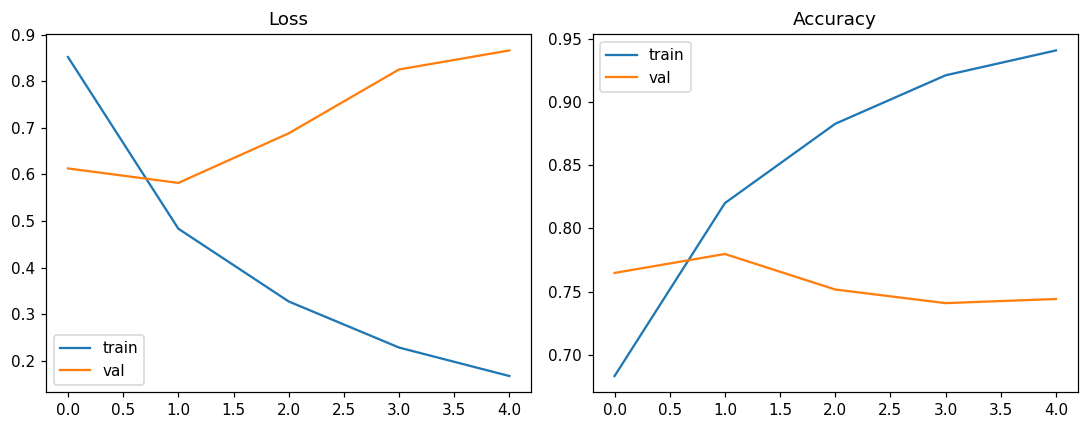

In [6]:
history = json.loads((METRICS_DIR / 'lstm_training_history.json').read_text())
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].plot(history['loss'], label='train'); axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history['accuracy'], label='train'); axes[1].plot(history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

Validation loss stops improving after epoch 1–2 while training loss keeps falling — textbook overfitting given only ~10K short training examples. Early stopping (`restore_best_weights=True`) protects the saved model from this, but it also caps how much the LSTM can ultimately learn from a dataset this size.

## 6. Confusion matrices

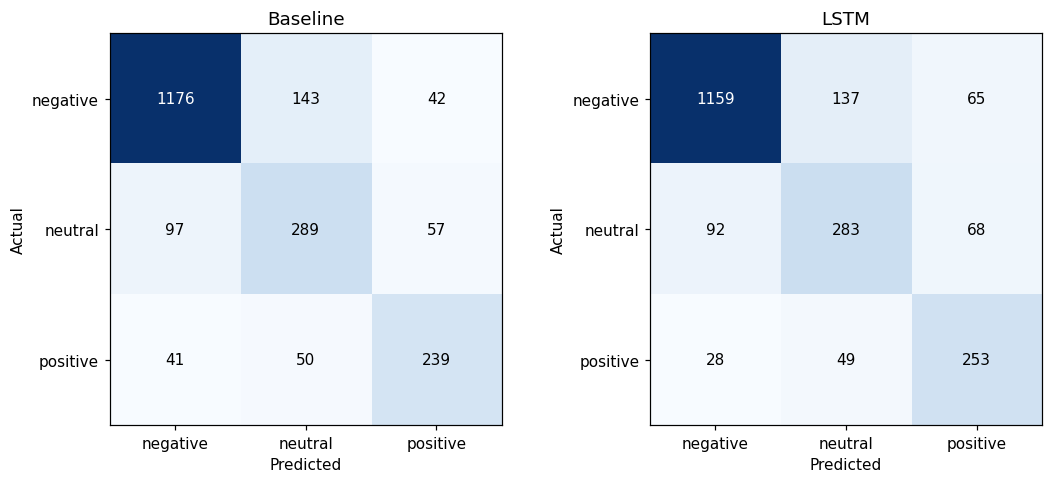

In [7]:
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(10,4.5))
for ax, key, title in zip(axes, ['baseline','lstm'], ['Baseline','LSTM']):
    cm = np.array(comparison[key]['confusion_matrix'])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(3)); ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticks(range(3)); ax.set_yticklabels(CLASS_NAMES)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout(); plt.show()

Both models' biggest confusion is **neutral vs. negative** — expected, since mildly annoyed-but-not-angry tweets sit right on that boundary and even human annotators disagree on borderline cases in this dataset.

## 7. Honest conclusion
On this dataset size (~10K training tweets after cleaning), the TF-IDF + Logistic Regression baseline is **competitive with, and slightly ahead of**, the bidirectional LSTM on raw accuracy and macro-F1. This is a genuine, reproducible finding — not a bug — and is exactly the kind of result a professional ML engineer reports honestly rather than suppresses. See `docs/model_card.md` and the README's *Future Improvements* section for the concrete next steps (pretrained embeddings, more data, transformer fine-tuning) that would be tried next in a real product setting.